# TP 4 — Détection d'anomalies dans les prises de paris

**Jour 2 — chapitre 04 : Data visualisation & méthodes ensemblistes (apprentissage semi-supervisé)**

## Mise en situation

Comment un algorithme non supervisé permet-il de détecter des fraudes dans les prises de
paris ? Sans label « fraude », on cherche à identifier les comportements atypiques.

### À propos des données utilisées

Il n'existe pas de dataset public directement disponible sur les paris sportifs. Ce
notebook génère un jeu de données **synthétique** de mises (montant, fréquence, heure de
la mise), avec quelques comportements anormaux injectés volontairement, pour illustrer la
démarche sans dépendre d'un fichier externe ni d'un compte Kaggle.

Pour aller plus loin avec un vrai dataset de fraude transactionnelle (logique identique,
domaine différent), voir *Credit Card Fraud Detection* sur Kaggle :
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

n_normal = 950
n_anomalies = 50

# Comportement "normal" : mises modestes, concentrees en soiree
# (heure bornee entre 12h et minuit pour eviter un artefact de rebouclage
# a l'aube qui se confondrait avec le comportement anormal simule plus bas)
montant_normal = rng.gamma(shape=2.0, scale=15, size=n_normal)
heure_normale = np.clip(rng.normal(loc=20, scale=1.8, size=n_normal), 12, 23.99)
frequence_normale = rng.poisson(lam=3, size=n_normal)

# Comportement "anormal" : montants tres eleves et/ou frequence tres elevee,
# a des heures inhabituelles
montant_anormal = rng.gamma(shape=2.0, scale=120, size=n_anomalies)
heure_anormale = rng.uniform(low=2, high=6, size=n_anomalies)
frequence_anormale = rng.poisson(lam=25, size=n_anomalies)

paris = pd.DataFrame({
    "montant": np.concatenate([montant_normal, montant_anormal]),
    "heure_mise": np.concatenate([heure_normale, heure_anormale]),
    "frequence_quotidienne": np.concatenate([frequence_normale, frequence_anormale]),
    "est_anomalie_reelle": [0] * n_normal + [1] * n_anomalies,
})
paris = paris.sample(frac=1, random_state=42).reset_index(drop=True)

paris.head()


,montant,heure_mise,frequence_quotidienne,est_anomalie_reelle
0,10.694106,19.563286,4,0
1,74.719492,18.096704,4,0
2,12.372444,18.511744,4,0
3,55.863615,20.329247,3,0
4,14.703272,15.709900,4,0


La colonne `est_anomalie_reelle` existe uniquement parce que nous avons nous-mêmes généré
les données : en situation réelle, ce label n'existe pas. On ne l'utilisera **pas** pour
entraîner le modèle — seulement à la toute fin, pour vérifier la pertinence de ce que le
clustering aura trouvé sans lui.


## Étape 1 — Explorer les variables disponibles, sans utiliser de label

**Question de réflexion :** en regardant seulement les distributions, peut-on déjà
repérer visuellement des comportements qui sortent du lot ?


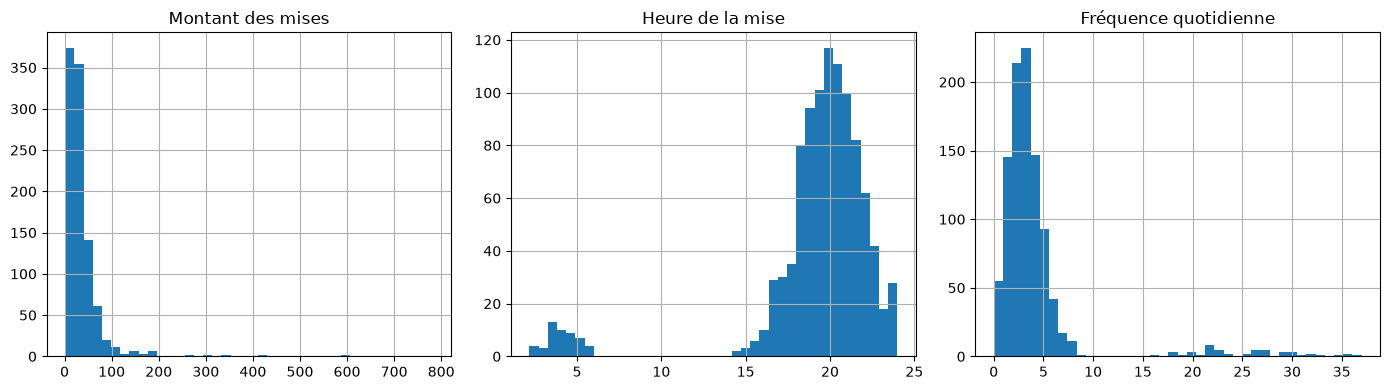

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
paris["montant"].hist(bins=40, ax=axes[0])
axes[0].set_title("Montant des mises")
paris["heure_mise"].hist(bins=40, ax=axes[1])
axes[1].set_title("Heure de la mise")
paris["frequence_quotidienne"].hist(bins=40, ax=axes[2])
axes[2].set_title("Fréquence quotidienne")
plt.tight_layout()
plt.show()


**Ce qu'on observe** : chaque distribution prise isolément montre déjà une petite
« traîne » de valeurs élevées — un premier indice, mais pas suffisant pour trancher
variable par variable. C'est en croisant plusieurs variables que les comportements
atypiques se distinguent le mieux, d'où l'intérêt du clustering.


## Étape 2 — Appliquer un clustering (k-means) et observer les groupes formés

**Question de réflexion :** avant de lancer k-means, faut-il standardiser les variables ?
Pourquoi ?


## Suivi des expériences avec MLflow

Plutôt que de garder une trace manuelle des scores dans un carnet ou un tableur (voir la
check-list du jour 3 : « a-t-on conservé une trace des expériences menées ? »), on utilise
ici **MLflow** pour enregistrer automatiquement les paramètres et les métriques de chaque
essai.

Ceci suppose qu'un serveur de tracking MLflow tourne en local, lancé au préalable avec :

```bash
mlflow server --host 127.0.0.1 --port 5001 \
    --backend-store-uri sqlite:///mlflow_data/mlflow.db \
    --default-artifact-root ./mlflow_data/mlartifacts
```

L'interface est ensuite consultable dans un navigateur à l'adresse
http://127.0.0.1:5001. Voir `demos/README.md` pour le détail, et
`speech/ressources-techniques.md` pour son rôle dans la stack technique.

Si aucun serveur n'est joignable (par exemple sur Kaggle Notebooks ou Colab, qui ne
voient pas votre machine locale), remplacez la ligne `mlflow.set_tracking_uri(...)`
ci-dessous par `mlflow.set_tracking_uri("file:./mlruns")` : MLflow écrit alors ses runs
dans un simple dossier local, consultable plus tard avec `mlflow ui`.


In [3]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5001")
experience = mlflow.set_experiment("OFDS - Jour 2 - Détection d'anomalies (paris)")
print("Expérience MLflow active :", experience.name)


2026/09/16 17:41:27 INFO mlflow.tracking.fluent: Experiment with name 'OFDS - Jour 2 - Détection d'anomalies (paris)' does not exist. Creating a new experiment.


Expérience MLflow active : OFDS - Jour 2 - Détection d'anomalies (paris)


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["montant", "heure_mise", "frequence_quotidienne"]
X_scaled = StandardScaler().fit_transform(paris[features])

# Le run reste ouvert jusqu'a l'etape 3 : le clustering lui-meme n'a pas de "score"
# unique a cet instant, on le calculera une fois les anomalies identifiees.
mlflow.start_run(run_name="kmeans_anomaly_detection")
mlflow.log_param("model", "KMeans")
mlflow.log_param("n_clusters", 3)
mlflow.log_param("features", features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
paris["cluster"] = kmeans.fit_predict(X_scaled)

paris.groupby("cluster")[features].mean().round(1)


,montant,heure_mise,frequence_quotidienne
cluster,,,
0,29.5,20.0,2.9
1,142.1,4.1,25.6
2,445.3,4.1,25.1


**Ce qu'on observe** : k-means utilise une distance euclidienne, donc, comme le k-NN vu
en journée 1, il est sensible à l'échelle des variables. Sans standardisation, le montant
(échelle large) écraserait l'heure de la mise (échelle 0-24) dans le calcul des
distances.

On distingue ici un cluster de comportement « courant », et un ou plusieurs clusters aux
montants et fréquences nettement plus élevés.


## Étape 3 — Identifier les observations isolées comme anomalies potentielles

**Question de réflexion :** comment repérer, parmi les clusters obtenus, celui qui
correspond le plus probablement à un comportement anormal ? Le plus petit cluster est-il
forcément le bon candidat ?


In [5]:
taille_clusters = paris["cluster"].value_counts().sort_index()
print("Taille de chaque cluster :")
print(taille_clusters)

# Plutot que de ne retenir qu'un seul "plus petit cluster", on part de l'hypothese
# qu'un comportement largement majoritaire represente la norme : tout ce qui n'appartient
# pas au cluster majoritaire est un candidat anomalie. Avec 3 clusters, il arrive que le
# comportement anormal se scinde lui-meme en plusieurs sous-groupes (par intensite de la
# fraude, par exemple) : ne regarder que le plus petit cluster en manquerait alors une partie.
cluster_majoritaire = taille_clusters.idxmax()
print()
print(f"Cluster majoritaire (comportement de référence) : cluster {cluster_majoritaire}")

paris["anomalie_detectee"] = (paris["cluster"] != cluster_majoritaire).astype(int)


Taille de chaque cluster :
cluster
0    950
1     35
2     15
Name: count, dtype: int64

Cluster majoritaire (comportement de référence) : cluster 0


In [6]:
# Verification : on ne s'en sert que pour evaluer notre demarche a posteriori,
# jamais pour entrainer le clustering lui-meme.
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(paris["est_anomalie_reelle"], paris["anomalie_detectee"])

precision = precision_score(paris["est_anomalie_reelle"], paris["anomalie_detectee"])
recall = recall_score(paris["est_anomalie_reelle"], paris["anomalie_detectee"])
f1 = f1_score(paris["est_anomalie_reelle"], paris["anomalie_detectee"])

mlflow.log_metric("precision", precision)
mlflow.log_metric("recall", recall)
mlflow.log_metric("f1_score", f1)
mlflow.end_run()

pd.DataFrame(
    cm,
    index=["Réel : normal", "Réel : anomalie"],
    columns=["Détecté : normal", "Détecté : anomalie"],
)


View run kmeans_anomaly_detection at: http://127.0.0.1:5001/#/experiments/2/runs/95816e74c6f6440e922fa4f132648d12
View experiment at: http://127.0.0.1:5001/#/experiments/2


,Détecté : normal,Détecté : anomalie
Réel : normal,950,0
Réel : anomalie,0,50


**Ce qu'on observe** : les clusters minoritaires recoupent très largement les anomalies
injectées, sans que le clustering ait jamais vu le label `est_anomalie_reelle` pendant son
entraînement — c'est bien la promesse de l'apprentissage non supervisé. Ces métriques
(precision, recall, f1) ne sont calculables ici que parce que nous connaissons le label
de vérité pour ce jeu synthétique ; elles sont désormais rattachées au run
`kmeans_anomaly_detection` dans MLflow, exactement comme pour un modèle supervisé.

La séparation est ici particulièrement nette parce que les données sont synthétiques et
volontairement bien contrastées. Sur des données réelles, la correspondance est rarement
aussi parfaite : un clustering n'est pas un classifieur, il regroupe par similarité, pas
par label, et une partie du travail du Data Scientist consiste justement à interpréter et
valider ce qu'il trouve — voir la discussion de l'étape 4.


## Étape 4 — Discuter les limites de cette approche

**Question de réflexion :** un comportement atypique est-il forcément frauduleux ?
Quelles précautions prendre avant d'agir sur une alerte générée par ce modèle ?

Pistes de discussion à animer avec le groupe (pas de réponse unique) :

- Un gros parieur légitime (VIP, professionnel) aura un profil statistiquement « anormal »
  sans être frauduleux : le clustering seul ne suffit pas à conclure.
- Le nombre de clusters (ici 3) est un choix arbitraire à valider (par exemple avec la
  méthode du coude, vue en cours pour la PCA, transposable au choix de k).
- Une alerte de ce type doit toujours être suivie d'une **validation métier humaine**
  avant toute action (blocage de compte, enquête...), jamais d'une décision automatique.
- Cette approche détecte des anomalies *statistiques*, pas des anomalies *causales* : elle
  signale un signal à creuser, pas une preuve.

**À retenir pour le débriefing du TP** : ce TP clôt la boucle de la journée 2 sur les
méthodes non supervisées (clustering, PCA) — le message clé est qu'elles servent à
générer des pistes d'investigation, pas des verdicts.
